# Calibrated Explanations: Factual SHAP Visualization Plugin Example

This notebook uses the installed SHAP explanation plugin and the installed SHAP visualization plugin.
It assumes both packages are available in the current environment:

- `calibrated-explanations-explanation-factual-shap`
- `calibrated-explanations-visualization-factual-shap`

In [1]:
import os

import calibrated_explanations.plugins.registry as registry

EXPLANATION_ID = "official.explanation.factual.shap"
STYLE_ID = "official.visualization.factual.shap"

# Trust and discover installed plugins via package entry points.
os.environ["CE_TRUST_PLUGIN"] = ",".join(
    [
        EXPLANATION_ID,
        STYLE_ID,
        "official.visualization.factual.shap.builder",
        "official.visualization.factual.shap.renderer",
    ]
)
registry.load_entrypoint_plugins(include_untrusted=False)

print("Explanation plugin loaded:", registry.find_explanation_descriptor(EXPLANATION_ID) is not None)
print("Visualization style loaded:", registry.find_plot_style_descriptor(STYLE_ID) is not None)

Explanation plugin loaded: True
Visualization style loaded: True


C:\Users\loftuw\CUDATemp\ipykernel_59440\465099900.py:17: UserWarning: Skipping untrusted plugin 'official.explanation.factual.shap' from official discovered via entrypoint. Set CE_TRUST_PLUGIN, add it to [tool.calibrated_explanations.plugins].trusted, or call trust_plugin('official.explanation.factual.shap') to load it.
  registry.load_entrypoint_plugins(include_untrusted=False)
C:\Users\loftuw\CUDATemp\ipykernel_59440\465099900.py:17: UserWarning: Skipping untrusted plugin 'official.visualization.factual.shap.bootstrap' from official discovered via entrypoint. Set CE_TRUST_PLUGIN, add it to [tool.calibrated_explanations.plugins].trusted, or call trust_plugin('official.visualization.factual.shap.bootstrap') to load it.
  registry.load_entrypoint_plugins(include_untrusted=False)


## Fit, Calibrate, and Explain

Use the normal `WrapCalibratedExplainer` workflow and point calibration at the installed SHAP explanation plugin.

In [2]:
from calibrated_explanations import WrapCalibratedExplainer
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=240,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    random_state=0,
)

X_train, X_test, y_train, _ = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y,
)
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=0,
    stratify=y_train,
)

model = WrapCalibratedExplainer(LogisticRegression(random_state=0, solver="liblinear"))
model.fit(X_fit, y_fit)
model.calibrate(X_cal, y_cal, mode="classification", factual_plugin=EXPLANATION_ID)

instances = X_test[:8]
explanations = model.explain_factual(instances)
print("Number of explanations:", len(explanations.explanations))

C:\Users\loftuw\Documents\Github\kristinebergs-calibrated_explanations\src\calibrated_explanations\core\explain\orchestrator.py:1790: UserWarning: Using untrusted explanation plugin 'official.explanation.factual.shap' via explicit override. Ensure you trust the source of this plugin.
  plugin, identifier = self.explainer.plugin_manager.resolve_explanation_plugin_for_mode(
ExactExplainer explainer: 9it [00:13,  1.74s/it]               


Number of explanations: 8


## Local SHAP Waterfall Plot

Render a SHAP-native waterfall plot through the separate visualization style.

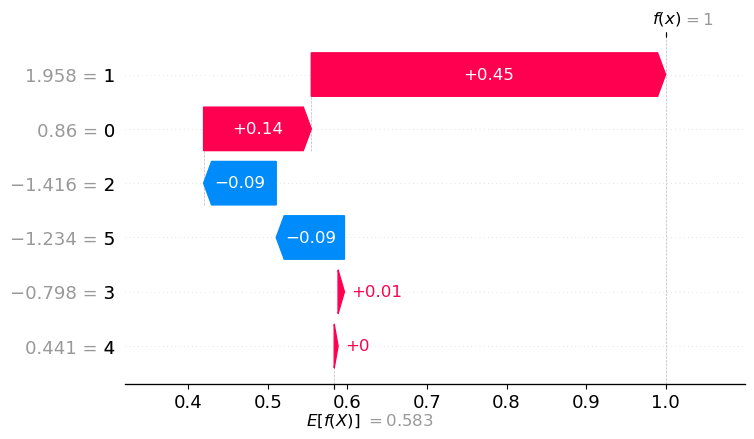

In [9]:
waterfall_result = explanations[0].plot(
    style=STYLE_ID,
    show=False,
    shap_kind="waterfall",
    shap_bound="center",
    max_display=6,
)
waterfall_result.figure

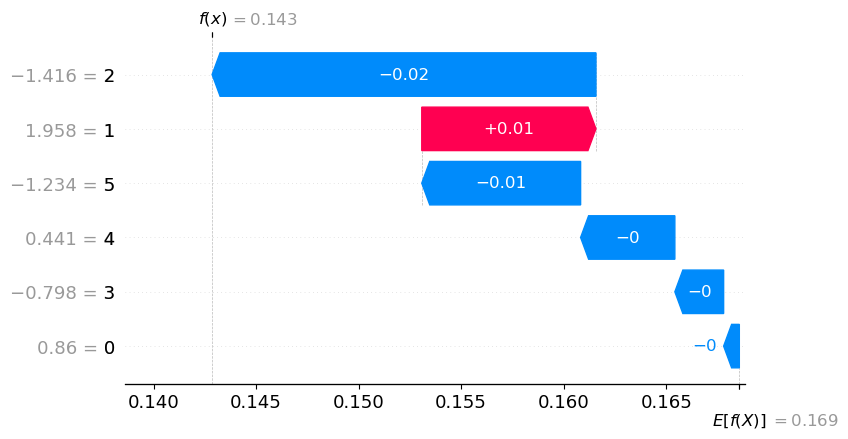

In [10]:
waterfall_result = explanations.plot(
    style=STYLE_ID,
    show=False,
    shap_kind="waterfall",
    shap_bound="uncertainty",
    instance_index=0,
    max_display=6,
)
waterfall_result.figure

## Multi-instance SHAP Beeswarm Plot

Render a global-style SHAP plot for the explanation collection.

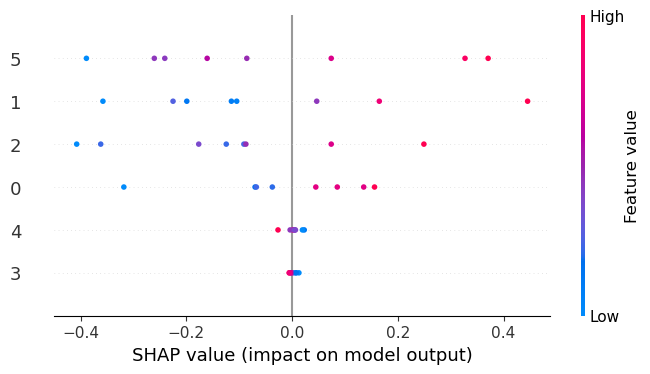

In [12]:
beeswarm_result = explanations.plot(
    style=STYLE_ID,
    show=False,
    shap_kind="beeswarm",
    shap_bound="center",
    max_display=6,
)
beeswarm_result.figure


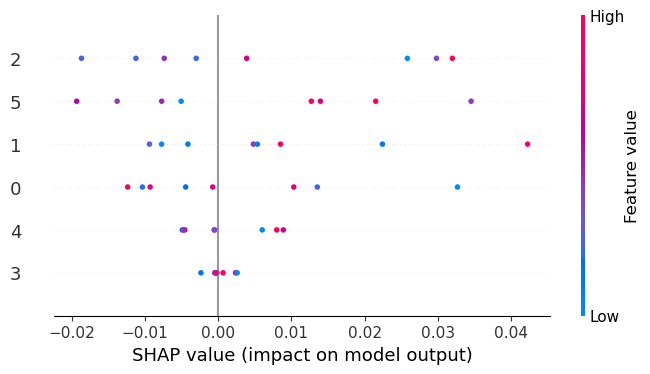

In [13]:
beeswarm_result = explanations.plot(
    style=STYLE_ID,
    show=False,
    shap_kind="beeswarm",
    shap_bound="uncertainty",
    max_display=6,
)
beeswarm_result.figure